# Quantitative Investment Analytics ETL Pipeline

Four Canadian equity portfolios, auditable SQL analytics, and purged volatility prediction. This notebook reads the last completed pipeline run. Charts are embedded as PNG outputs for notebook viewers. See the source modules for the executable implementation.

In [1]:
from pathlib import Path
import json, sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline
ROOT = Path.cwd()
if not (ROOT / 'output').exists():
    ROOT = ROOT.parent
manifest = json.loads((ROOT / 'output/run_manifest.json').read_text())
print(manifest['source']['source'])
print(manifest['config'])
conn = sqlite3.connect(ROOT / 'output/investment_analytics.db')
summary = pd.read_sql('SELECT * FROM portfolio_summary', conn)
display(summary)

Yahoo Finance via yfinance
{'start': '2018-01-01', 'end': '2026-09-01', 'benchmark': 'XIC.TO', 'initial_capital': 100000, 'risk_free_rate': 0.03, 'transaction_cost_bps': 10, 'warmup_days': 252, 'forecast_days': 20, 'test_fraction': 0.2, 'simulation_years': 5, 'simulation_paths': 5000, 'bootstrap_block_days': 20, 'trading_days': 252, 'seed': 42}


,cumulative_return,annualized_return,volatility,sharpe,max_drawdown,portfolio_id,total_cost,turnover,excess_annualized_return
0,2.798174,0.191215,0.162911,0.974572,-0.287301,Balanced,776.605214,3.625783,0.028992
1,2.147465,0.162223,0.163749,0.820370,-0.372117,Benchmark,0.000000,0.000000,0.000000
2,5.492029,0.277950,0.286007,0.897374,-0.487163,Growth,1856.877502,5.196306,0.115728
3,2.129369,0.161344,0.160645,0.827860,-0.330561,Income,395.514165,2.350359,-0.000878
4,2.435912,0.175662,0.152889,0.942033,-0.297091,Low volatility,573.676954,2.992934,0.013439


## Portfolio performance and drawdown
Previous-close weights earn daily returns. Month-start rebalancing deducts costs. These are selected equity allocations, not an optimized investment recommendation.

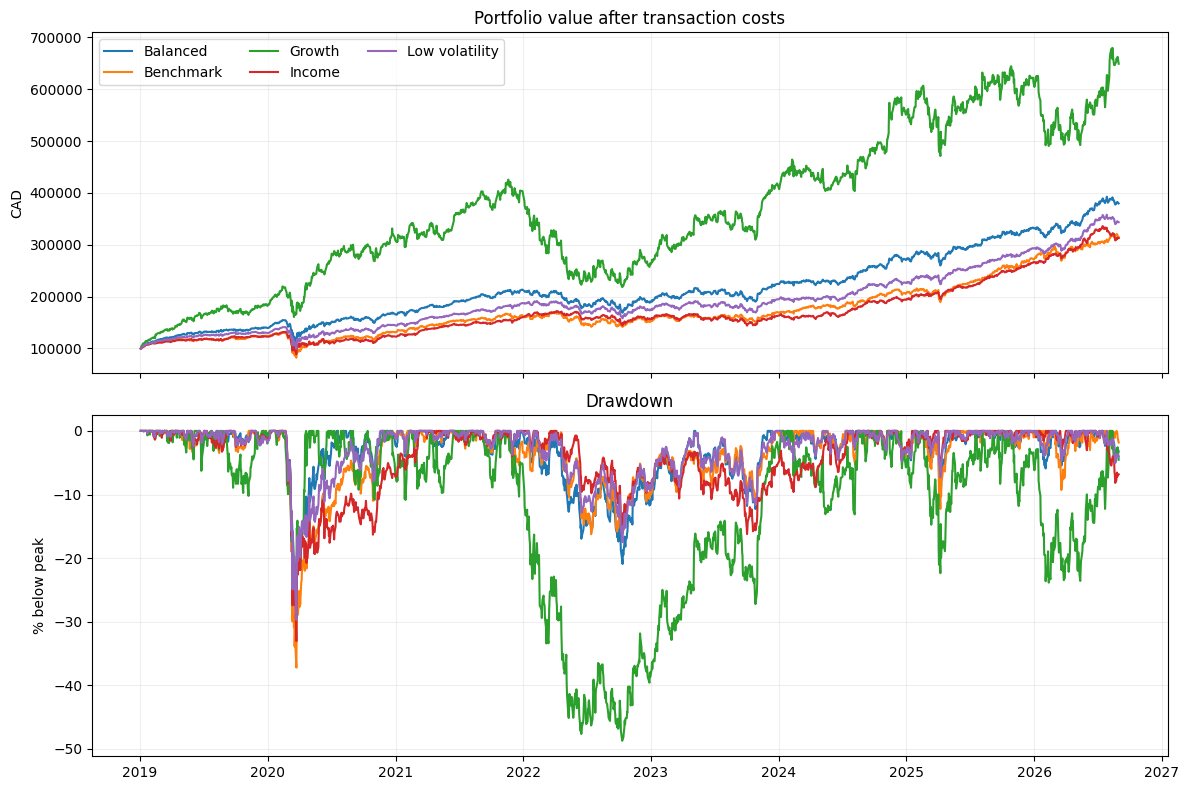

In [2]:
daily = pd.read_sql('SELECT * FROM portfolio_daily_summary ORDER BY date', conn, parse_dates=['date'])
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for name, group in daily.groupby('portfolio_id'):
    axes[0].plot(group.date, group.nav, label=name)
    axes[1].plot(group.date, group.drawdown * 100, label=name)
axes[0].set(title='Portfolio value after transaction costs', ylabel='CAD')
axes[1].set(title='Drawdown', ylabel='% below peak')
axes[0].legend(ncol=3)
for ax in axes: ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

## History and five-year scenarios
The historical backtest ends before any simulated return. All portfolios and XIC share sampled 20-session blocks. Scenario medians are conditional on the historical sample; strong past growth is carried forward, not independently forecast. The normalized chart removes unequal starting NAV. Ranges omit parameter uncertainty and unseen regimes. The horizon is exactly five calendar years with 252 modeled steps per year, not exchange calendar dates.

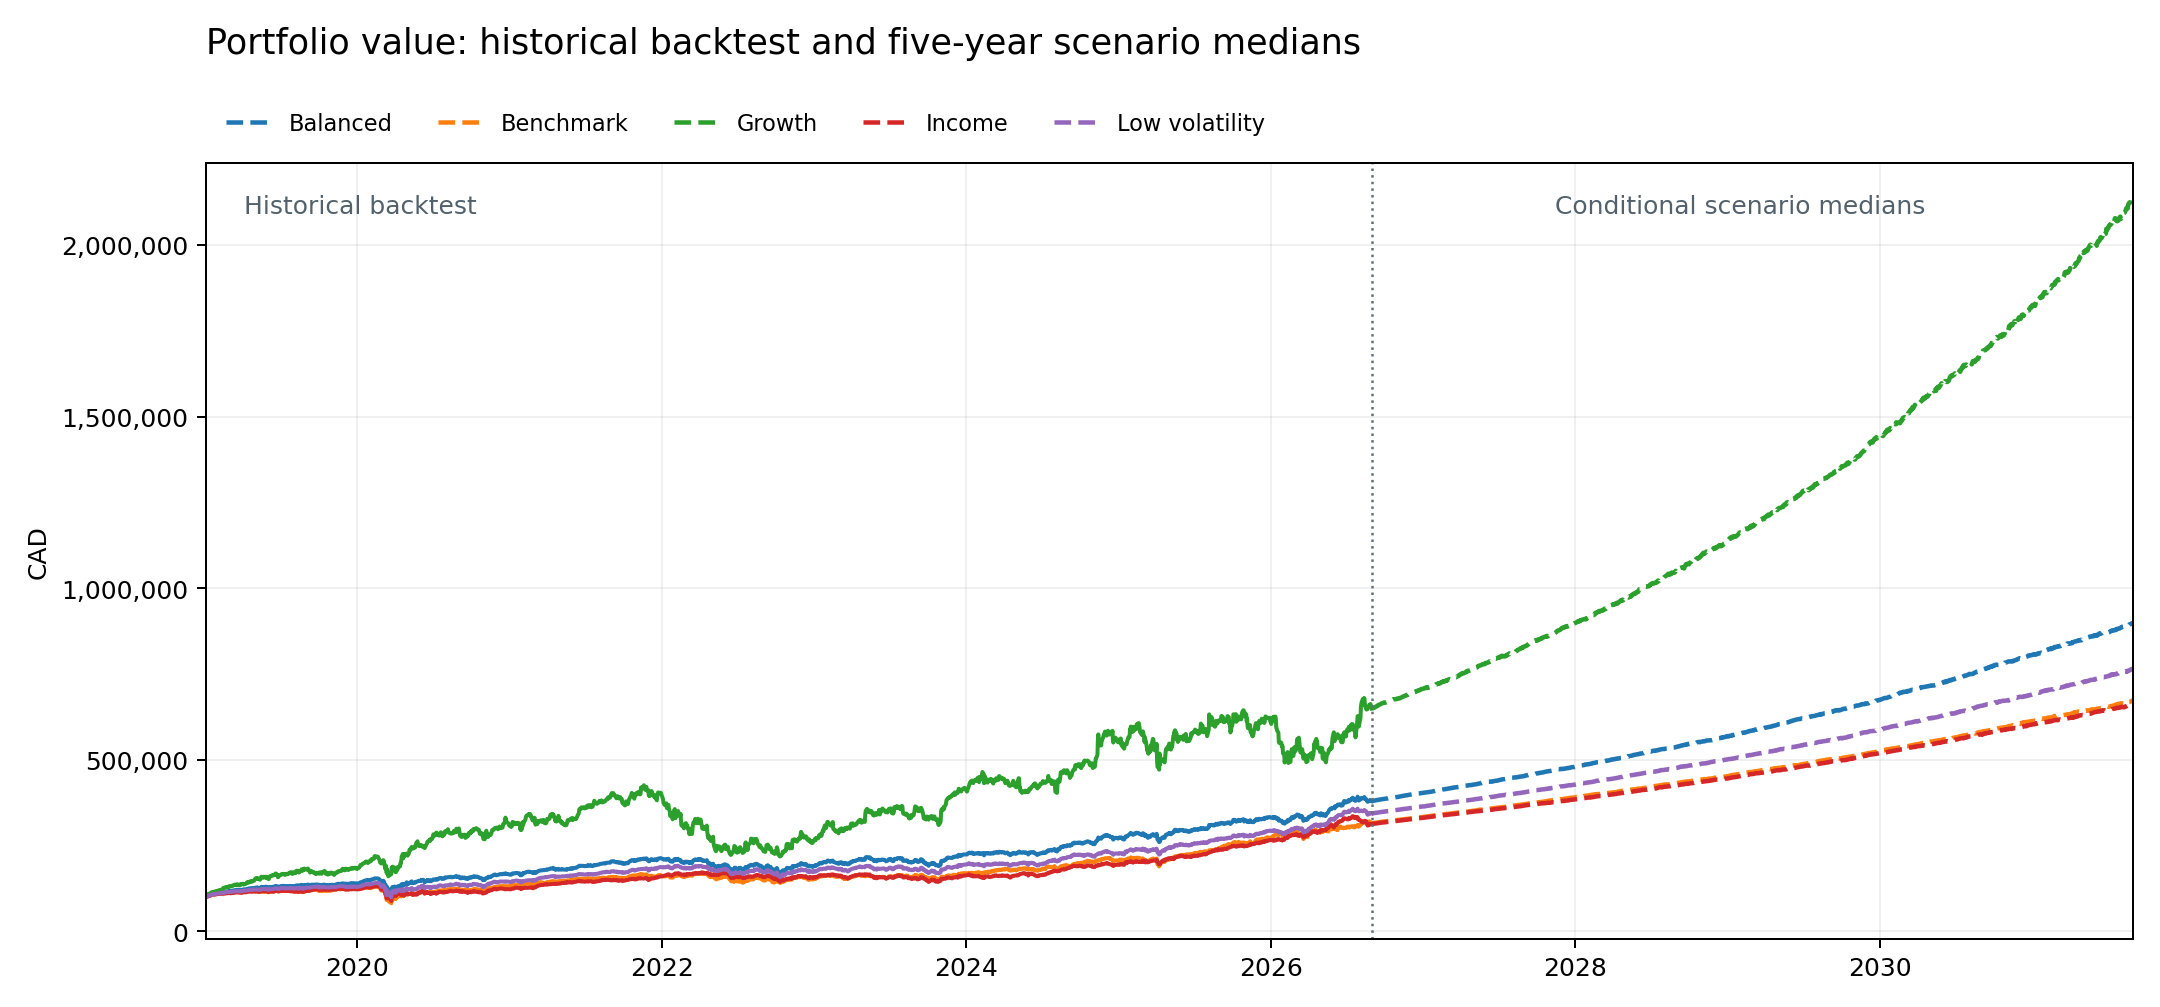

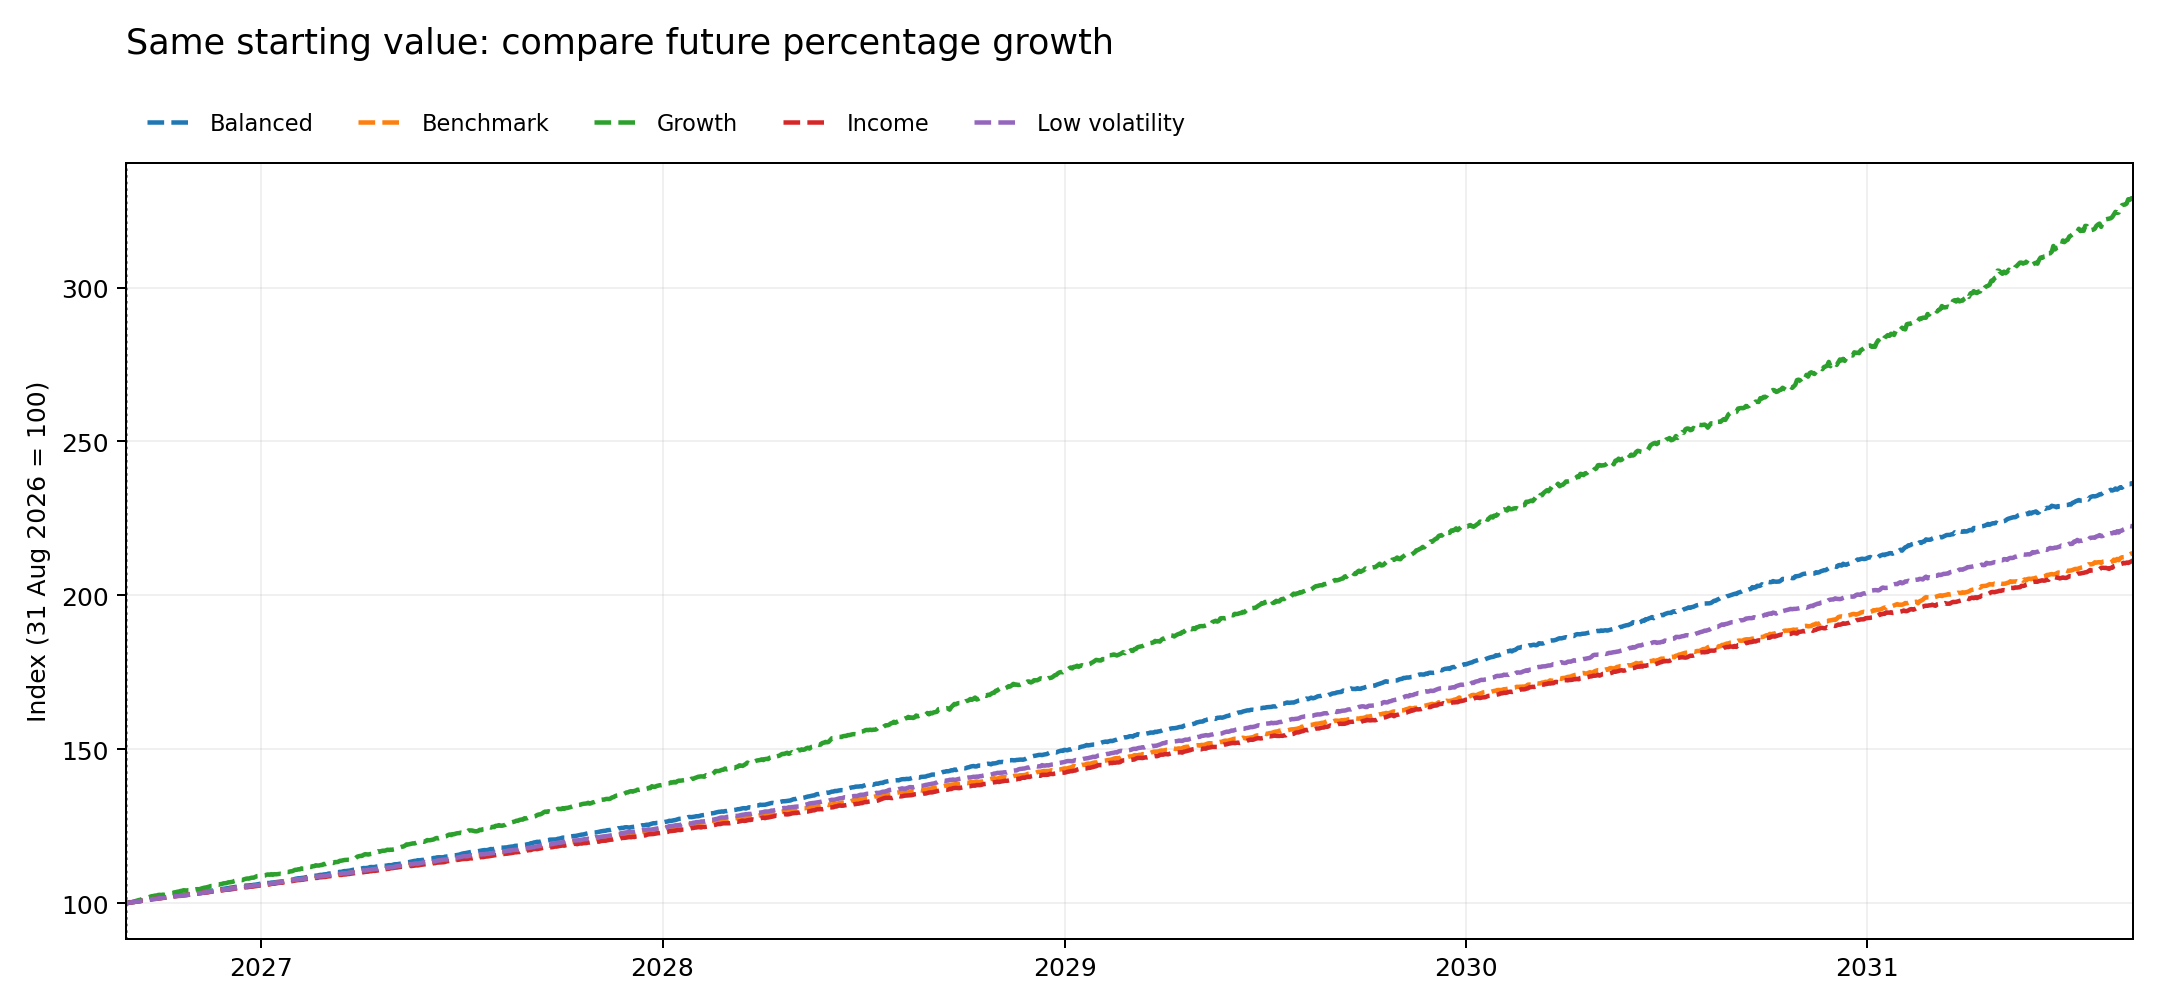

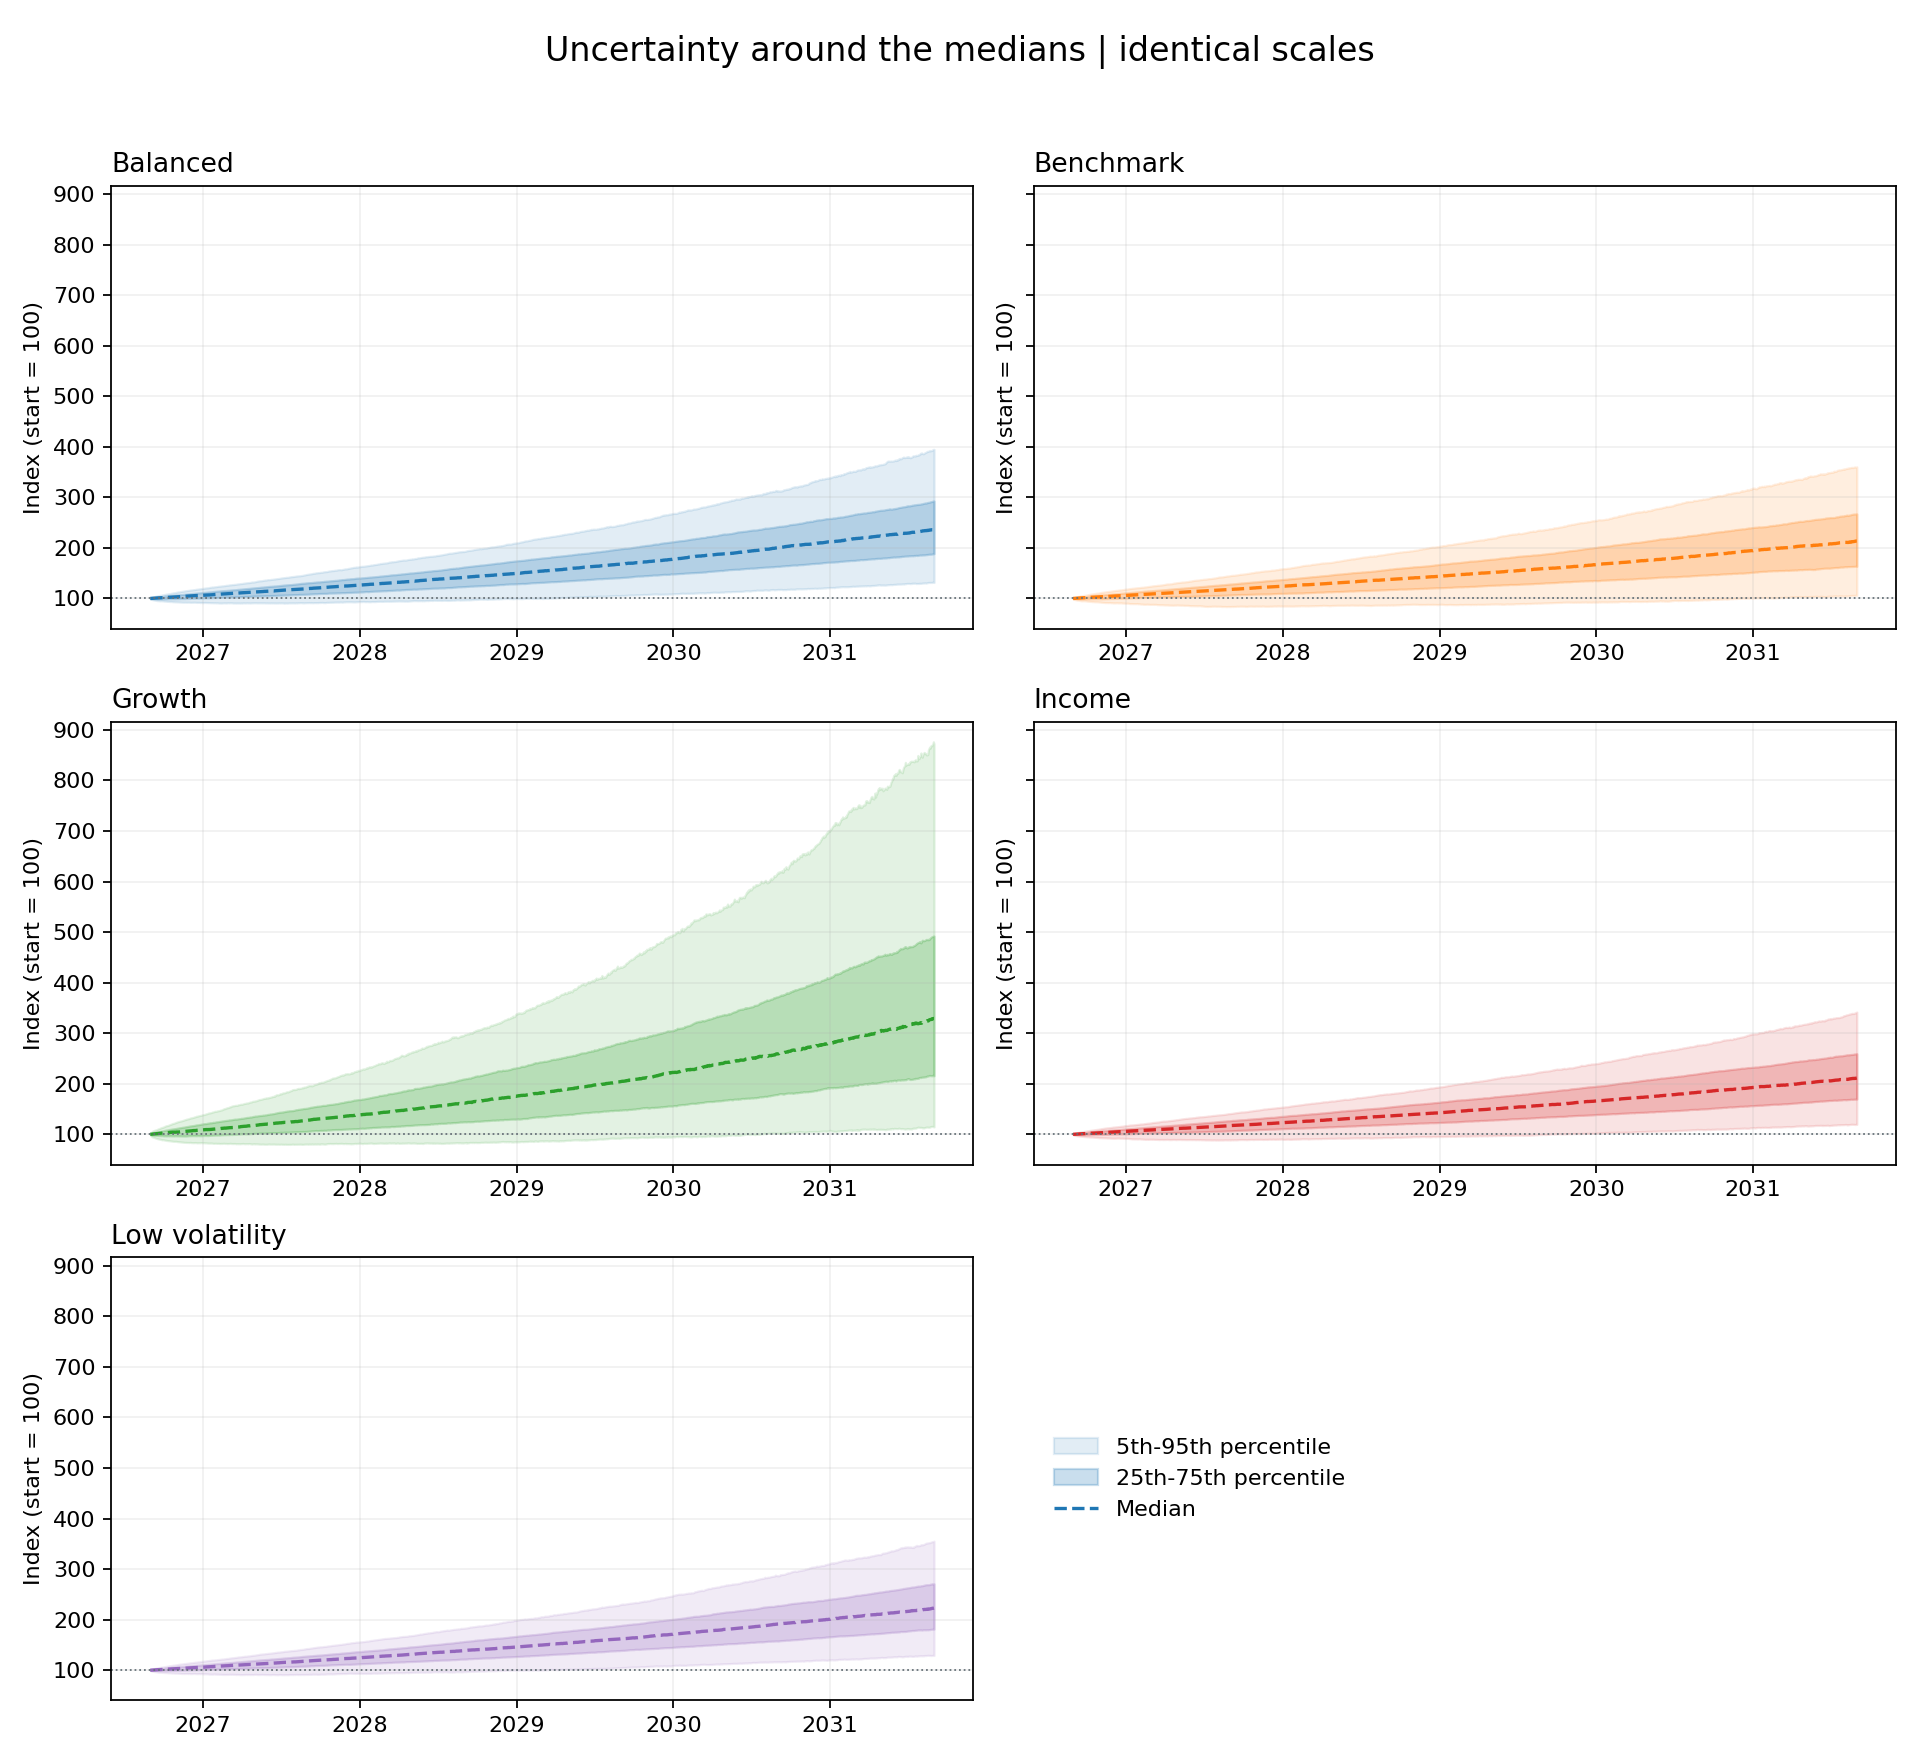

,portfolio_id,as_of_date,start_value,terminal_p05,terminal_median,terminal_p95,probability_terminal_loss,median_max_drawdown,scenario_paths,horizon_years,bootstrap_block_days
0,Balanced,2026-08-31 00:00:00,379817.394119,500084.874497,8.961326e+05,1.500102e+06,0.0072,-0.202865,5000,5,20
1,Benchmark,2026-08-31 00:00:00,314746.547784,334203.693991,6.725454e+05,1.134191e+06,0.0392,-0.242438,5000,5,20
2,Growth,2026-08-31 00:00:00,649202.888680,744686.632749,2.135893e+06,5.663396e+06,0.0308,-0.335489,5000,5,20
3,Income,2026-08-31 00:00:00,312936.910414,374579.250589,6.613889e+05,1.069487e+06,0.0156,-0.221340,5000,5,20
4,Low volatility,2026-08-31 00:00:00,343591.229452,443392.110582,7.650389e+05,1.220606e+06,0.0084,-0.194353,5000,5,20


In [3]:
from IPython.display import Image
for filename in ['forward_scenarios.png', 'forward_indexed.png', 'forward_ranges.png']:
    display(Image(filename=str(ROOT / 'output' / filename)))
display(pd.read_sql('SELECT * FROM forward_projection_summary', conn))

## Backtesting and look-ahead controls
Returns use previous-close weights; low-volatility targets use only the initial calibration window. Later prices cannot affect earlier weights. Regression labels are purged at chronological split boundaries and scaling stays within training folds. These timing controls do not remove retrospectively chosen securities, manual allocations or survivorship bias. Five-year scenarios use completed history at the final as-of date, never feed into earlier decisions, and have not been validated as five-year forecasts.

## SQL data mart
The view joins position facts to the security dimension. Monthly returns use a CTE and LAG over month-end NAV.

-- Latest allocations, with sector names obtained from the security dimension.
CREATE VIEW latest_sector_exposure AS
WITH latest AS (SELECT MAX(date) AS date FROM portfolio_positions)
SELECT p.portfolio_id, s.sector, SUM(p.market_value) AS market_value,
       SUM(p.weight) AS weight
FROM portfolio_positions p
JOIN securities s ON s.ticker = p.ticker
JOIN latest l ON l.date = p.date
GROUP BY p.portfolio_id, s.sector;

-- Compound monthly returns from month-end NAV using a window function.
CREATE VIEW monthly_portfolio_returns AS
WITH ranked AS (
 SELECT *, SUBSTR(date, 1, 7) AS month,
 ROW_NUMBER() OVER (PARTITION BY portfolio_id, SUBSTR(date, 1, 7) ORDER BY date DESC) AS rn
 FROM portfolio_daily_summary
), endpoints AS (
 SELECT portfolio_id, month, nav FROM ranked WHERE rn = 1
)
SELECT portfolio_id, month, nav,
 nav / LAG(nav) OVER (PARTITION BY portfolio_id ORDER BY month) - 1 AS monthly_return
FROM endpoints;

-- Daily cross-sectional ranking by trailing annualized volatility.
CREA

,portfolio_id,sector,market_value,weight
0,Balanced,Energy,54729.056875,0.144093
1,Balanced,Financials,94183.667480,0.247971
2,Balanced,Industrials,55795.837249,0.146902
3,Balanced,Technology,82793.440689,0.217982
4,Balanced,Utilities,92315.391825,0.243052
5,Benchmark,Benchmark,314746.547784,1.000000
6,Growth,Financials,90212.881038,0.138959
7,Growth,Industrials,120383.907598,0.185433
8,Growth,Technology,438606.100043,0.675607
9,Income,Energy,61403.248725,0.196216


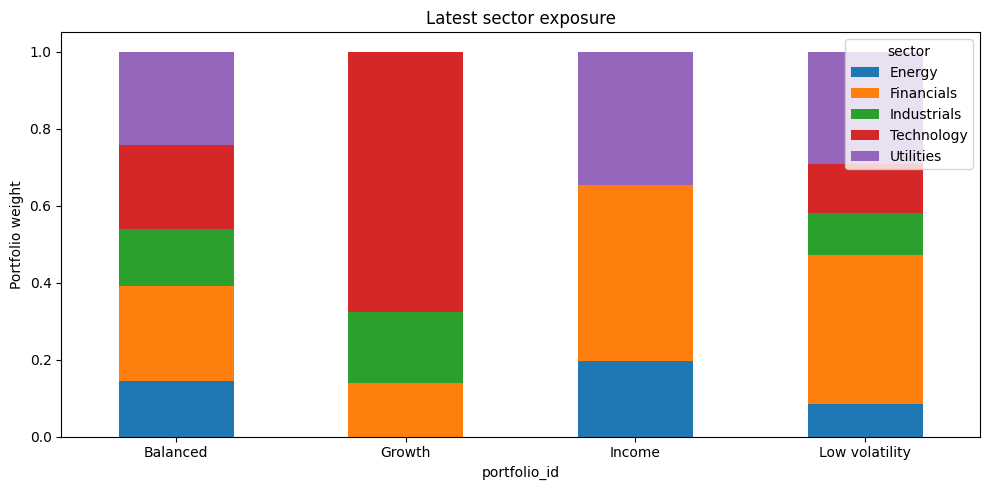

In [4]:
print((ROOT / 'sql/analysis_queries.sql').read_text())
exposure = pd.read_sql('SELECT * FROM latest_sector_exposure', conn)
display(exposure)
exposure[exposure.portfolio_id != 'Benchmark'].pivot(index='portfolio_id', columns='sector', values='weight').plot.bar(stacked=True, figsize=(10, 5))
plt.title('Latest sector exposure')
plt.ylabel('Portfolio weight')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Machine learning validation
Predict next-20-session volatility from past returns, volatility and market volume. All scaling is inside cross-validation. Training labels end before validation begins. Compare held-out RMSE with persistence; ML may lose.

,portfolio_id,model,rmse,r2,selected_by_cv
0,Balanced,Linear regression,0.043156,-0.087686,0
1,Balanced,Ridge,0.041783,-0.019568,1
2,Balanced,Lasso,0.041799,-0.020322,0
3,Balanced,ElasticNet,0.042053,-0.032806,0
4,Balanced,Persistence baseline,0.049813,-0.449087,0
5,Growth,Linear regression,0.099861,-0.057570,0
6,Growth,Ridge,0.099264,-0.044973,1
7,Growth,Lasso,0.099706,-0.054298,0
8,Growth,ElasticNet,0.099741,-0.055036,0
9,Growth,Persistence baseline,0.131365,-0.830095,0


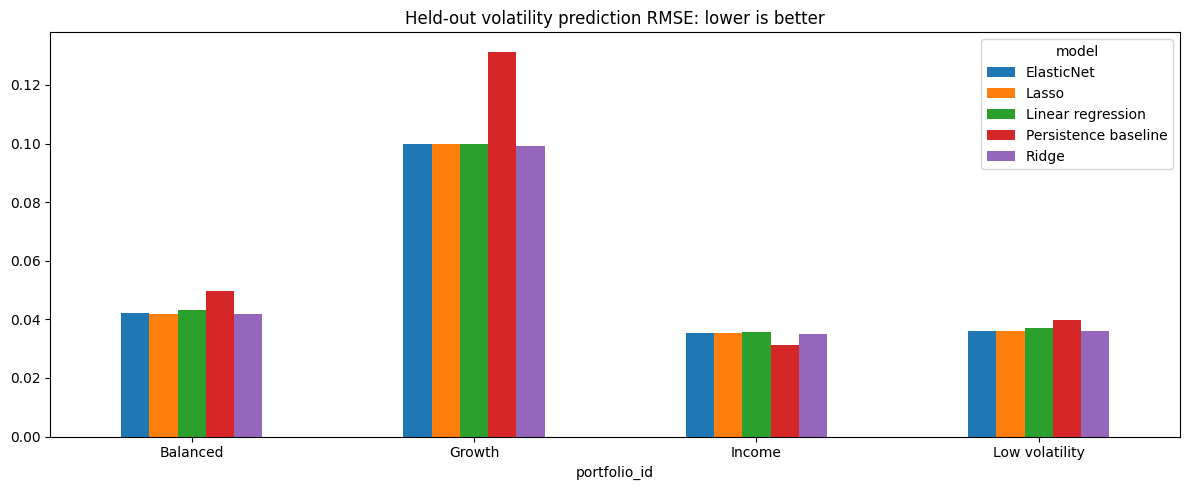

,portfolio_id,fold,train_start,last_train_label,validation_start,validation_end
0,Balanced,0,2019-01-30 00:00:00,2020-04-07 00:00:00,2020-04-08 00:00:00,2021-06-14 00:00:00
1,Balanced,1,2019-01-30 00:00:00,2021-06-14 00:00:00,2021-06-15 00:00:00,2022-08-19 00:00:00
2,Balanced,2,2019-01-30 00:00:00,2022-08-19 00:00:00,2022-08-22 00:00:00,2023-10-26 00:00:00
3,Balanced,3,2019-01-30 00:00:00,2023-10-26 00:00:00,2023-10-27 00:00:00,2025-01-02 00:00:00
4,Growth,0,2019-01-30 00:00:00,2020-04-07 00:00:00,2020-04-08 00:00:00,2021-06-14 00:00:00
5,Growth,1,2019-01-30 00:00:00,2021-06-14 00:00:00,2021-06-15 00:00:00,2022-08-19 00:00:00
6,Growth,2,2019-01-30 00:00:00,2022-08-19 00:00:00,2022-08-22 00:00:00,2023-10-26 00:00:00
7,Growth,3,2019-01-30 00:00:00,2023-10-26 00:00:00,2023-10-27 00:00:00,2025-01-02 00:00:00
8,Income,0,2019-01-30 00:00:00,2020-04-07 00:00:00,2020-04-08 00:00:00,2021-06-14 00:00:00
9,Income,1,2019-01-30 00:00:00,2021-06-14 00:00:00,2021-06-15 00:00:00,2022-08-19 00:00:00


In [5]:
scores = pd.read_sql('SELECT * FROM model_scores', conn)
display(scores[['portfolio_id', 'model', 'rmse', 'r2', 'selected_by_cv']])
scores.pivot(index='portfolio_id', columns='model', values='rmse').plot.bar(figsize=(12, 5))
plt.title('Held-out volatility prediction RMSE: lower is better')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
display(pd.read_sql('SELECT * FROM validation_splits', conn))

## Implementation
The following cells display the actual pipeline source used to generate these results.

### extract.py
```python
import hashlib
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd


def extract(root, config, source):
    securities = pd.read_csv(root / "data/securities.csv")
    holdings = pd.read_csv(root / "data/holdings.csv")
    path = root / "data" / ("synthetic_prices.csv" if source == "synthetic" else "cached_prices.csv")
    metadata_path = path.with_suffix(".json")
    if source == "download":
        import yfinance as yf
        frames = []
        for ticker in securities.ticker:
            data = yf.download(ticker, start=config["start"], end=config["end"],
                               auto_adjust=False, progress=False, threads=False)
            if data.empty:
                raise ValueError(f"No market data returned for {ticker}; use --source synthetic explicitly for a demo.")
            if isinstance(data.columns, pd.MultiIndex):
                data.columns = data.columns.get_level_values(0)
            frames.append(pd.DataFrame({"date": data.index.strftime("%Y-%m-%d"),
                                        "ticker": ticker, "adjusted_price": data["Adj Close"].to_numpy(),
                                        "volume": data.Volume.to_numpy()}))
        prices = pd.concat(frames, ignore_index=True)
    elif source == "synthetic":
        rng = np.random.default_rng(config["seed"])
        dates = pd.bdate_range(config["start"], pd.Timestamp(config["end"]) - pd.Timedelta(days=1))
        market = rng.normal(0.00025, 0.01, len(dates))
        frames = []
        for row in securities.itertuples():
            scale = {"Technology": 0.018, "Utilities": 0.006}.get(row.sector, 0.009)
            r = market * (0.65 if row.sector == "Utilities" else 1) + rng.normal(0, scale, len(dates))
            frames.append(pd.DataFrame({"date": dates, "ticker": row.ticker,
                                        "adjusted_price": 100 * np.cumprod(1 + r),
                                        "volume": rng.integers(100000, 3000000, len(dates))}))
        prices = pd.concat(frames, ignore_index=True)
    else:
        prices = pd.read_csv(path)
        metadata = json.loads(metadata_path.read_text())
        if metadata["sha256"] != hashlib.sha256(path.read_bytes()).hexdigest():
            raise ValueError("Cached price checksum does not match provenance metadata")
        return prices, holdings, securities, metadata
    prices.to_csv(path, index=False)
    metadata = {"source": "Yahoo Finance via yfinance" if source == "download" else "SYNTHETIC DEMONSTRATION",
                "retrieved_at": datetime.now(timezone.utc).isoformat(),
                "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
                "start": config["start"], "end_exclusive": config["end"],
                "price_basis": "Dividend/split adjusted close; CAD"}
    metadata_path.write_text(json.dumps(metadata, indent=2))
    return prices, holdings, securities, metadata

```

### validation.py
```python
import numpy as np
import pandas as pd


def clean_inputs(prices, holdings, securities):
    prices = prices.copy()
    prices["date"] = pd.to_datetime(prices.date, errors="raise")
    for col in ("adjusted_price", "volume"):
        prices[col] = pd.to_numeric(prices[col], errors="raise")
    if prices.isna().any().any() or not np.isfinite(prices[["adjusted_price", "volume"]]).all().all():
        raise ValueError("Missing or non-finite price fields")
    if not prices.adjusted_price.gt(0).all() or not prices.volume.ge(0).all():
        raise ValueError("Prices must be positive and volume nonnegative")
    before = len(prices)
    prices = prices.drop_duplicates()
    if prices.duplicated(["date", "ticker"]).any():
        raise ValueError("Conflicting duplicate ticker-date records")
    if securities.ticker.duplicated().any() or securities.isna().any().any():
        raise ValueError("Invalid security master")
    if set(prices.ticker) != set(securities.ticker):
        raise ValueError("Price universe does not match security master")
    if holdings.isna().any().any() or holdings.duplicated(["portfolio_id", "ticker"]).any():
        raise ValueError("Invalid or duplicate holdings")
    if not set(holdings.ticker) <= set(securities.ticker):
        raise ValueError("Unknown security in holdings")
    if not np.isfinite(holdings.target_weight).all() or not holdings.target_weight.ge(0).all():
        raise ValueError("Holdings must have finite nonnegative weights")
    if not np.allclose(holdings.groupby("portfolio_id").target_weight.sum(), 1):
        raise ValueError("Portfolio weights must sum to one")
    if set(securities.currency) != {"CAD"}:
        raise ValueError("This pipeline requires a single CAD currency basis")
    prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)
    wide = prices.pivot(index="date", columns="ticker", values="adjusted_price")
    if wide.isna().any().any():
        raise ValueError("Missing ticker-date prices; repair the source instead of silently filling")
    return prices, {"exact_duplicates_removed": before - len(prices), "missing_prices": 0,
                    "price_records": len(prices), "securities": len(securities), "dates": len(wide)}


def validate_outputs(daily, positions):
    if not np.isfinite(daily[["net_return", "nav"]]).all().all() or not daily.nav.gt(0).all():
        raise ValueError("Invalid portfolio results")
    if not np.allclose(positions.groupby(["date", "portfolio_id"]).weight.sum(), 1):
        raise ValueError("Position weights do not reconcile")
    totals = positions.groupby(["date", "portfolio_id"]).market_value.sum()
    expected = daily.set_index(["date", "portfolio_id"]).nav.reindex(totals.index)
    if not np.allclose(totals, expected):
        raise ValueError("Position values do not reconcile to NAV")

```

### analytics.py
```python
import numpy as np
import pandas as pd


def metrics(returns, risk_free_rate=0.03):
    returns = pd.Series(returns).dropna()
    wealth = (1 + returns).cumprod()
    drawdown = wealth / wealth.cummax().clip(lower=1) - 1
    std = returns.std(ddof=1)
    rf_daily = (1 + risk_free_rate) ** (1 / 252) - 1
    return {"cumulative_return": wealth.iloc[-1] - 1,
            "annualized_return": wealth.iloc[-1] ** (252 / len(returns)) - 1,
            "volatility": std * np.sqrt(252),
            "sharpe": (returns.mean() - rf_daily) / std * np.sqrt(252) if std > 0 else np.nan,
            "max_drawdown": drawdown.min()}


def security_analytics(prices):
    groups = []
    for _, group in prices.groupby("ticker", sort=True):
        group = group.sort_values("date").copy()
        group["daily_return"] = group.adjusted_price.pct_change(fill_method=None)
        group["cumulative_return"] = group.adjusted_price / group.adjusted_price.iloc[0] - 1
        group["moving_average_20"] = group.adjusted_price.rolling(20).mean()
        group["rolling_volatility_20"] = group.daily_return.rolling(20).std() * np.sqrt(252)
        group["drawdown"] = group.adjusted_price / group.adjusted_price.cummax() - 1
        group["max_drawdown_to_date"] = group.drawdown.cummin()
        group["average_volume_20"] = group.volume.rolling(20).mean()
        groups.append(group)
    return pd.concat(groups, ignore_index=True)


def portfolio_analytics(prices, holdings, securities, config):
    wide = prices.pivot(index="date", columns="ticker", values="adjusted_price").sort_index()
    returns = wide.pct_change(fill_method=None)
    warmup = config["warmup_days"]
    if len(wide) < warmup + 300:
        raise ValueError("At least 300 evaluation days plus the warmup period are required")
    assets = sorted(set(wide.columns) - {config["benchmark"]})
    targets = {name: group.set_index("ticker").target_weight.reindex(wide.columns, fill_value=0)
               for name, group in holdings.groupby("portfolio_id")}
    # Freeze inverse-volatility weights using only pre-investment observations.
    inv = 1 / returns.iloc[1:warmup + 1][assets].std()
    if not np.isfinite(inv).all():
        raise ValueError("Low-volatility calibration requires nonzero finite volatility")
    targets["Low volatility"] = (inv / inv.sum()).reindex(wide.columns, fill_value=0)
    targets["Benchmark"] = pd.Series({config["benchmark"]: 1.0}).reindex(wide.columns, fill_value=0)
    rows, position_rows, trades = [], [], []
    for name, target in targets.items():
        nav, weights = config["initial_capital"], target.copy()
        initial_date = wide.index[warmup]
        # Initial positions are assumed funded at the calibration close; entry cost excluded for all strategies.
        rows.append({"date": initial_date, "portfolio_id": name, "nav": nav,
                     "gross_return": 0., "net_return": 0., "turnover": 0., "cost": 0.})
        for date in wide.index[warmup + 1:]:
            r = returns.loc[date]
            gross = float(weights @ r)
            before_cost = nav * (1 + gross)
            drifted = weights * (1 + r) / (1 + gross)
            index = wide.index.get_loc(date)
            rebalance = date.month != wide.index[index - 1].month and name != "Benchmark"
            turnover = float((target - drifted).abs().sum()) if rebalance else 0.
            cost = before_cost * turnover * config["transaction_cost_bps"] / 10000
            new_nav = before_cost - cost
            rows.append({"date": date, "portfolio_id": name, "nav": new_nav,
                         "gross_return": gross, "net_return": new_nav / nav - 1,
                         "turnover": turnover, "cost": cost})
            if rebalance:
                trades.append({"date": date, "portfolio_id": name, "turnover": turnover, "cost": cost})
            weights = target.copy() if rebalance else drifted
            nav = new_nav
            for ticker in wide.columns:
                if weights[ticker] > 0:
                    position_rows.append({"date": date, "portfolio_id": name, "ticker": ticker,
                                          "adjusted_units": nav * weights[ticker] / wide.loc[date, ticker],
                                          "market_value": nav * weights[ticker], "weight": weights[ticker]})
    daily = pd.DataFrame(rows)
    daily["cumulative_return"] = daily.nav / config["initial_capital"] - 1
    daily["drawdown"] = daily.nav / daily.groupby("portfolio_id").nav.cummax() - 1
    positions = pd.DataFrame(position_rows).merge(securities, on="ticker", validate="many_to_one")
    sectors = positions.groupby(["date", "portfolio_id", "sector"], as_index=False).agg(
        market_value=("market_value", "sum"), weight=("weight", "sum"))
    summary = []
    for name, group in daily.groupby("portfolio_id"):
        row = metrics(group.net_return.iloc[1:], config["risk_free_rate"])
        row.update(portfolio_id=name, total_cost=group.cost.sum(), turnover=group.turnover.sum())
        summary.append(row)
    summary = pd.DataFrame(summary)
    benchmark_return = summary.loc[summary.portfolio_id == "Benchmark", "annualized_return"].iloc[0]
    summary["excess_annualized_return"] = summary.annualized_return - benchmark_return
    target_table = pd.concat([v.rename("weight").rename_axis("ticker").reset_index().assign(portfolio_id=k)
                              for k, v in targets.items()], ignore_index=True)
    return daily, positions, sectors, summary, pd.DataFrame(trades), target_table

```

### forward.py
```python
"""Forward-looking portfolio scenarios built from completed historical returns."""

import numpy as np
import pandas as pd


def forward_scenarios(daily, config):
    """Create deterministic block-bootstrap projections without using future data.

    The simulation starts immediately after the final backtest date. Consecutive
    blocks of realized net returns preserve short-run market behaviour while the
    percentile bands communicate uncertainty rather than a point prediction.
    """
    paths = int(config["simulation_paths"])
    days = int(config["simulation_years"] * config["trading_days"])
    block = int(config["bootstrap_block_days"])
    if paths < 100 or days < 1 or block < 1:
        raise ValueError("Invalid forward-scenario configuration")

    actual = daily.sort_values(["date", "portfolio_id"]).copy()
    returns = actual.pivot(index="date", columns="portfolio_id", values="net_return").iloc[1:]
    starts = actual.groupby("portfolio_id").nav.last()
    if len(returns) < block:
        raise ValueError("Not enough completed return history for the selected bootstrap block")

    # Map 252 modeled sessions per year to an exact calendar horizon, not an exchange calendar.
    dates = pd.date_range(returns.index.max(), returns.index.max() + pd.DateOffset(years=int(config["simulation_years"])), periods=days + 1)
    rng = np.random.default_rng(config["seed"])
    blocks_needed = int(np.ceil(days / block))
    block_starts = rng.integers(0, len(returns) - block + 1, size=(paths, blocks_needed))
    sampled_index = (block_starts[:, :, None] + np.arange(block)).reshape(paths, -1)[:, :days]
    quantiles = [0.05, 0.25, 0.50, 0.75, 0.95]
    bands, summaries = [], []
    for portfolio_id in returns.columns:
        series = returns[portfolio_id].to_numpy(dtype=float)
        sampled_returns = series[sampled_index]
        values = starts[portfolio_id] * np.cumprod(1 + sampled_returns, axis=1)
        values = np.column_stack([np.full(paths, starts[portfolio_id]), values])
        percentile_values = np.quantile(values, quantiles, axis=0)
        bands.append(pd.DataFrame({
            "date": dates,
            "portfolio_id": portfolio_id,
            "p05": percentile_values[0],
            "p25": percentile_values[1],
            "median": percentile_values[2],
            "p75": percentile_values[3],
            "p95": percentile_values[4],
        }))
        drawdowns = values / np.maximum.accumulate(values, axis=1) - 1
        terminal = values[:, -1]
        summaries.append({
            "portfolio_id": portfolio_id,
            "as_of_date": returns.index.max(),
            "start_value": starts[portfolio_id],
            "terminal_p05": np.quantile(terminal, 0.05),
            "terminal_median": np.quantile(terminal, 0.50),
            "terminal_p95": np.quantile(terminal, 0.95),
            "probability_terminal_loss": np.mean(terminal < starts[portfolio_id]),
            "median_max_drawdown": np.quantile(drawdowns.min(axis=1), 0.50),
            "scenario_paths": paths,
            "horizon_years": config["simulation_years"],
            "bootstrap_block_days": block,
        })
    return pd.concat(bands, ignore_index=True), pd.DataFrame(summaries)

```

### models.py
```python
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


FEATURES = ["return_1", "return_5", "return_20", "volatility_20", "market_return_20", "volume_ratio"]


def feature_frame(group, benchmark, volume, horizon):
    r = group.set_index("date").net_return.sort_index()
    frame = pd.DataFrame({"return_1": r, "return_5": (1 + r).rolling(5).apply(np.prod, raw=True) - 1,
                          "return_20": (1 + r).rolling(20).apply(np.prod, raw=True) - 1,
                          "volatility_20": r.rolling(20).std() * np.sqrt(252),
                          "market_return_20": (1 + benchmark).rolling(20).apply(np.prod, raw=True) - 1,
                          "volume_ratio": volume / volume.rolling(20).mean()})
    # The label at t contains returns t+1 through t+h; purge h rows at every split.
    frame["target"] = r.rolling(horizon).std().shift(-horizon) * np.sqrt(252)
    frame["target_end"] = pd.Series(r.index, index=r.index).shift(-horizon)
    return frame.replace([np.inf, -np.inf], np.nan).dropna()


def fit_models(daily, prices, config):
    benchmark = daily[daily.portfolio_id == "Benchmark"].set_index("date").net_return
    volume = prices[prices.ticker == config["benchmark"]].set_index("date").volume
    horizon = config["forecast_days"]
    scores, predictions, coefficients, audits = [], [], [], []
    candidates = {"Linear regression": (LinearRegression(), {}),
                  "Ridge": (Ridge(), {"model__alpha": [0.1, 1., 10., 100.]}),
                  "Lasso": (Lasso(max_iter=20000), {"model__alpha": [0.00001, 0.0001, 0.001]}),
                  "ElasticNet": (ElasticNet(max_iter=20000),
                                 {"model__alpha": [0.0001, 0.001], "model__l1_ratio": [0.25, 0.75]})}
    for name, group in daily.groupby("portfolio_id"):
        if name == "Benchmark":
            continue
        frame = feature_frame(group, benchmark, volume, horizon)
        split = int(len(frame) * (1 - config["test_fraction"]))
        train, test = frame.iloc[:split - horizon], frame.iloc[split:]
        if len(train) < 150 or len(test) < 30:
            raise ValueError("Insufficient history for purged chronological validation")
        if train.target_end.max() >= test.index.min():
            raise ValueError("Training labels overlap the test period")
        cv = TimeSeriesSplit(n_splits=4, gap=horizon)
        for fold, (tr, va) in enumerate(cv.split(train)):
            if train.iloc[tr].target_end.max() >= train.iloc[va].index.min():
                raise ValueError("Cross-validation label leakage")
            audits.append({"portfolio_id": name, "fold": fold, "train_start": train.iloc[tr].index.min(),
                           "last_train_label": train.iloc[tr].target_end.max(),
                           "validation_start": train.iloc[va].index.min(), "validation_end": train.iloc[va].index.max()})
        models = {}
        for model_name, (model, grid) in candidates.items():
            search = GridSearchCV(Pipeline([("scale", StandardScaler()), ("model", model)]), grid,
                                  cv=cv, scoring="neg_mean_squared_error", n_jobs=1)
            search.fit(train[FEATURES], train.target)
            models[model_name] = (np.maximum(search.predict(test[FEATURES]), 0), -search.best_score_, str(search.best_params_))
            for feature, value in zip(FEATURES, search.best_estimator_.named_steps["model"].coef_):
                coefficients.append({"portfolio_id": name, "model": model_name,
                                     "feature": feature, "coefficient": value})
        selected = min(models, key=lambda key: models[key][1])
        models["Persistence baseline"] = (test.volatility_20.to_numpy(), np.nan, "Trailing 20-day volatility")
        for model_name, (prediction, cv_mse, params) in models.items():
            scores.append({"portfolio_id": name, "model": model_name,
                           "rmse": np.sqrt(mean_squared_error(test.target, prediction)),
                           "r2": r2_score(test.target, prediction), "cv_mse": cv_mse,
                           "selected_by_cv": model_name == selected, "parameters": params,
                           "train_end": train.index[-1], "last_train_label": train.target_end.max(),
                           "test_start": test.index[0], "test_end": test.index[-1], "test_rows": len(test)})
            predictions.extend({"date": date, "portfolio_id": name, "model": model_name,
                                "actual": actual, "prediction": value}
                               for date, actual, value in zip(test.index, test.target, prediction))
    return pd.DataFrame(scores), pd.DataFrame(predictions), pd.DataFrame(coefficients), pd.DataFrame(audits)

```

### load.py
```python
import os
import sqlite3


def load_mart(output, tables, queries):
    path = output / "investment_analytics.db"
    temporary = output / "investment_analytics.tmp.db"
    try:
        with sqlite3.connect(temporary) as conn:
            if path.exists():
                with sqlite3.connect(path) as old:
                    old.backup(conn)
            for view in ("latest_sector_exposure", "monthly_portfolio_returns", "volatility_ranking", "rolling_portfolio_returns"):
                conn.execute(f'DROP VIEW IF EXISTS "{view}"')
            for name, frame in tables.items():
                frame.to_sql(name, conn, if_exists="append" if name == "pipeline_runs" else "replace", index=False)
            conn.executescript(queries)
            conn.execute("CREATE UNIQUE INDEX IF NOT EXISTS security_date ON security_daily_analytics(ticker, date)")
            conn.execute("CREATE UNIQUE INDEX IF NOT EXISTS portfolio_date ON portfolio_daily_summary(portfolio_id, date)")
            if conn.execute("PRAGMA integrity_check").fetchone()[0] != "ok":
                raise ValueError("SQLite integrity check failed")
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)

```

### pipeline.py
```python
import argparse
import hashlib
import json
import logging
import time
import uuid
from importlib.metadata import version
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd

from .analytics import portfolio_analytics, security_analytics
from .extract import extract
from .forward import forward_scenarios
from .load import load_mart
from .models import fit_models
from .report import render_report
from .validation import clean_inputs, validate_outputs


def run(root, source="cached", config_path=None):
    started = time.perf_counter()
    output = root / "output"
    output.mkdir(exist_ok=True)
    config = json.loads((config_path or root / "config.json").read_text())
    if not (0 < config["test_fraction"] < 0.5 and config["forecast_days"] >= 2
            and config["initial_capital"] > 0 and config["transaction_cost_bps"] >= 0
            and config["risk_free_rate"] > -1 and config["warmup_days"] >= 20
            and config["simulation_years"] >= 1 and config["simulation_paths"] >= 100
            and config["bootstrap_block_days"] >= 1 and config["trading_days"] >= 1):
        raise ValueError("Invalid research configuration")
    run_id = str(uuid.uuid4())
    logging.info("[1/9] Extracting prices, holdings and security metadata")
    prices, holdings, securities, provenance = extract(root, config, source)
    prices = prices[(pd.to_datetime(prices.date) >= config["start"]) & (pd.to_datetime(prices.date) < config["end"])]
    logging.info("[2/9] Cleaning and validating inputs")
    prices, quality = clean_inputs(prices, holdings, securities)
    logging.info("[3/9] Calculating security analytics")
    security = security_analytics(prices)
    logging.info("[4/9] Simulating portfolios and transaction costs")
    daily, positions, sectors, summary, trades, targets = portfolio_analytics(prices, holdings, securities, config)
    logging.info("[5/9] Validating NAV and allocation reconciliation")
    validate_outputs(daily, positions)
    logging.info("[6/9] Training models with purged time-series validation")
    scores, predictions, coefficients, audits = fit_models(daily, prices, config)
    logging.info("[7/9] Simulating five-year portfolio scenarios from completed history")
    projection_bands, projection_summary = forward_scenarios(daily, config)
    tables = {"securities": securities, "holdings": holdings, "security_daily_analytics": security,
              "portfolio_positions": positions, "portfolio_daily_summary": daily,
              "sector_exposures": sectors, "portfolio_summary": summary, "rebalancing_history": trades,
              "target_weights": targets, "model_scores": scores, "model_predictions": predictions,
              "model_coefficients": coefficients, "validation_splits": audits,
              "forward_projection_bands": projection_bands, "forward_projection_summary": projection_summary}
    logging.info("[8/9] Generating offline report and CSV exports")
    charts = render_report(output, tables, provenance, config, quality)
    for name, frame in tables.items():
        frame.to_csv(output / f"{name}.csv", index=False)
    manifest = {"run_id": run_id, "timestamp": datetime.now(timezone.utc).isoformat(),
                "source": provenance, "config": config, "validation": quality,
                "package_versions": {package: version(package) for package in ("pandas", "numpy", "scipy", "scikit-learn", "plotly", "yfinance")},
                "source_hashes": {path.name: hashlib.sha256(path.read_bytes()).hexdigest() for path in (root / "src").glob("*.py")},
                "input_hashes": {name: hashlib.sha256((root / "data" / name).read_bytes()).hexdigest()
                                 for name in ("holdings.csv", "securities.csv")}}
    (output / "run_manifest.json").write_text(json.dumps(manifest, indent=2))
    tables["pipeline_runs"] = pd.DataFrame([{"run_id": run_id, "timestamp": manifest["timestamp"],
                                            "status": "success", "price_rows": len(prices),
                                            "source": provenance["source"], "manifest": json.dumps(manifest)}])
    logging.info("[9/9] Loading SQL data mart")
    load_mart(output, tables, (root / "sql/analysis_queries.sql").read_text())
    logging.info("Pipeline complete: %s prices; %.1f seconds; report: %s", len(prices), time.perf_counter() - started, output / "report.html")
    return tables, charts


def main():
    parser = argparse.ArgumentParser(description="Investment analytics ETL and volatility forecasting")
    parser.add_argument("--source", choices=["cached", "download", "synthetic"], default="cached")
    parser.add_argument("--config", type=Path)
    args = parser.parse_args()
    root = Path(__file__).resolve().parents[1]
    (root / "output").mkdir(exist_ok=True)
    logging.basicConfig(level=logging.INFO, format="%(asctime)s %(message)s",
                        handlers=[logging.StreamHandler(), logging.FileHandler(root / "output/pipeline.log")])
    try:
        run(root, args.source, args.config)
    except Exception:
        logging.exception("Pipeline failed")
        raise


if __name__ == "__main__":
    main()

```

In [6]:
conn.close()